# Employee Attrition & Retention Analytics Dataset Analysis and Prediction

## Summary

In this notebook i take a look at the [Employee Attrition & Retention Analytics Dataset](https://www.kaggle.com/datasets/ajinkyachintawar/employee-attrition-and-retention-analytics-dataset/data) and predict the Attrition (left the Company or not) from the Features. For this I use a RandomForest and Logistic Regression Model. Aferwards I take a look at the finished models metrics trough visuailising them.

## Content
- [Data Loading](#data-loading)
- [Exploratory Data Analysis](#exploratory-data-analysis)
- [Preprocessing for Training](#preprocessing-for-training)
- [Logistic Regression Model](#logistic-regression-training)
- [Random Forest Model](#random-forest-model)
- [Compare Roc Curves](#compare-roc-curves)

In [323]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,roc_auc_score,classification_report,roc_curve
from sklearn.preprocessing import StandardScaler,OneHotEncoder,LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

## Data Loading

In [324]:
df = pd.read_csv("../Datasets/HR-Employee-Attrition.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102.0,Sales,1.0,2.0,Life Sciences,1.0,1.0,...,1.0,80.0,0.0,8.0,0.0,1.0,6.0,4.0,0.0,5.0
1,49,No,Travel_Frequently,279.0,Research & Development,8.0,1.0,Life Sciences,1.0,2.0,...,4.0,80.0,1.0,10.0,3.0,3.0,10.0,7.0,1.0,7.0
2,37,Yes,Travel_Rarely,1373.0,Research & Development,2.0,2.0,Other,1.0,4.0,...,2.0,80.0,0.0,7.0,3.0,3.0,0.0,0.0,0.0,0.0
3,33,No,Travel_Frequently,1392.0,Research & Development,3.0,4.0,Life Sciences,1.0,5.0,...,3.0,80.0,0.0,8.0,3.0,3.0,8.0,7.0,3.0,0.0
4,27,No,Travel_Rarely,591.0,Research & Development,2.0,1.0,Medical,1.0,7.0,...,4.0,80.0,1.0,6.0,3.0,3.0,2.0,2.0,2.0,2.0


In [325]:
df["Attrition"].value_counts()

Attrition
No        1233
Yes        237
 10:07       1
 15:16       1
 12:15       1
 14:15       1
 10:09       1
 16:24       1
Name: count, dtype: int64

In [326]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1476 entries, 0 to 1475
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1476 non-null   object 
 1   Attrition                 1476 non-null   object 
 2   BusinessTravel            1470 non-null   object 
 3   DailyRate                 1470 non-null   float64
 4   Department                1470 non-null   object 
 5   DistanceFromHome          1470 non-null   float64
 6   Education                 1470 non-null   float64
 7   EducationField            1470 non-null   object 
 8   EmployeeCount             1470 non-null   float64
 9   EmployeeNumber            1470 non-null   float64
 10  EnvironmentSatisfaction   1470 non-null   float64
 11  Gender                    1470 non-null   object 
 12  HourlyRate                1470 non-null   float64
 13  JobInvolvement            1470 non-null   float64
 14  JobLevel

In [327]:
#Convert Age to numeric type
df["Age"] = pd.to_numeric(df['Age'],errors="coerce")

In [328]:
df.isnull().sum()
#since there a six values missing we will drop them
df.dropna(inplace=True)
#df = df.reset_index(drop=True)
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41.0,Yes,Travel_Rarely,1102.0,Sales,1.0,2.0,Life Sciences,1.0,1.0,...,1.0,80.0,0.0,8.0,0.0,1.0,6.0,4.0,0.0,5.0
1,49.0,No,Travel_Frequently,279.0,Research & Development,8.0,1.0,Life Sciences,1.0,2.0,...,4.0,80.0,1.0,10.0,3.0,3.0,10.0,7.0,1.0,7.0
2,37.0,Yes,Travel_Rarely,1373.0,Research & Development,2.0,2.0,Other,1.0,4.0,...,2.0,80.0,0.0,7.0,3.0,3.0,0.0,0.0,0.0,0.0
3,33.0,No,Travel_Frequently,1392.0,Research & Development,3.0,4.0,Life Sciences,1.0,5.0,...,3.0,80.0,0.0,8.0,3.0,3.0,8.0,7.0,3.0,0.0
4,27.0,No,Travel_Rarely,591.0,Research & Development,2.0,1.0,Medical,1.0,7.0,...,4.0,80.0,1.0,6.0,3.0,3.0,2.0,2.0,2.0,2.0


In [329]:
# Preprocess Target Value
# Encode Target Attrition into Yes=1 and No = 0
le = LabelEncoder()
df["Attrition"] = le.fit_transform(df["Attrition"])
#df[df["Attrition"]==1]
df.ffill()
df["Attrition"].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

In [330]:
df["Attrition"].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

## Exploratory Data Analysis

In [331]:
# Numeric columns
num_list = df.select_dtypes(include=np.number).columns.tolist()
# remove target value from list
num_list.remove("Attrition")
print(num_list)
# Object Columns
obj_list = df.select_dtypes(include="object").columns.tolist()
print(obj_list)

['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


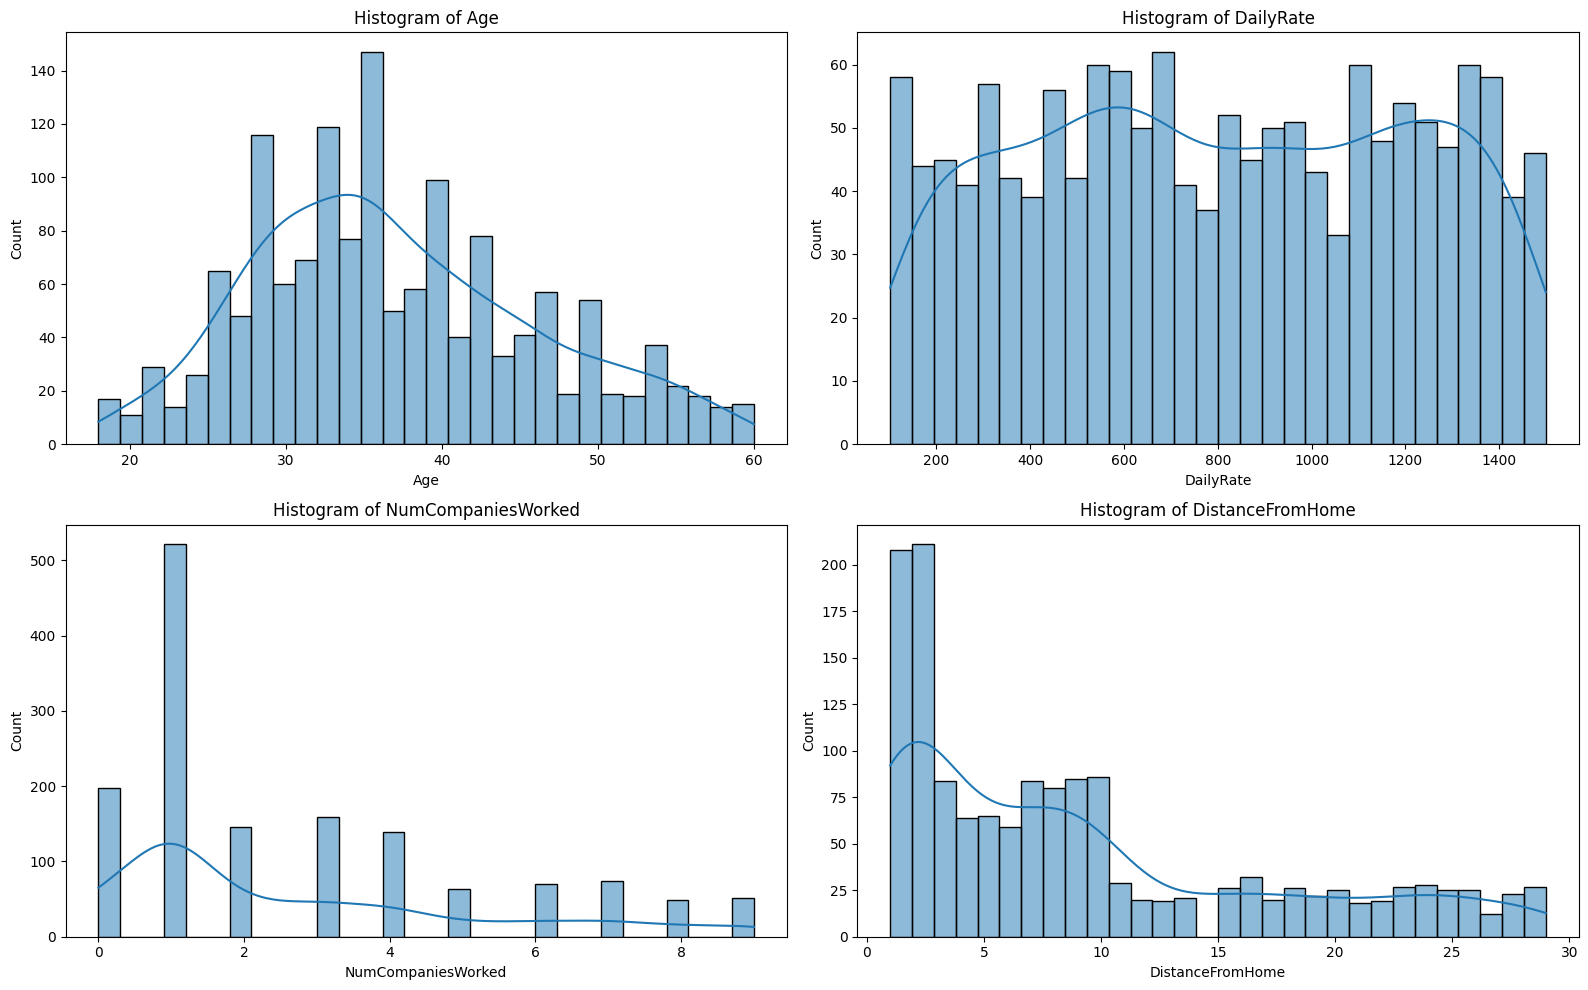

In [332]:
# lets select a few numeric columns to plot them
import math
list=['Age',"DailyRate","NumCompaniesWorked",'DistanceFromHome']

#Histplots
ncols = 2
nrows = math.ceil(len(list) / ncols)

plt.figure(figsize=(16, nrows * 5))
for i, col in enumerate(list):
    ax = plt.subplot(nrows, ncols, i + 1)
    sns.histplot(data=df,x=col, kde=True, bins=30)
    ax.set_title(f'Histogram of {col}')
plt.tight_layout()
plt.show()


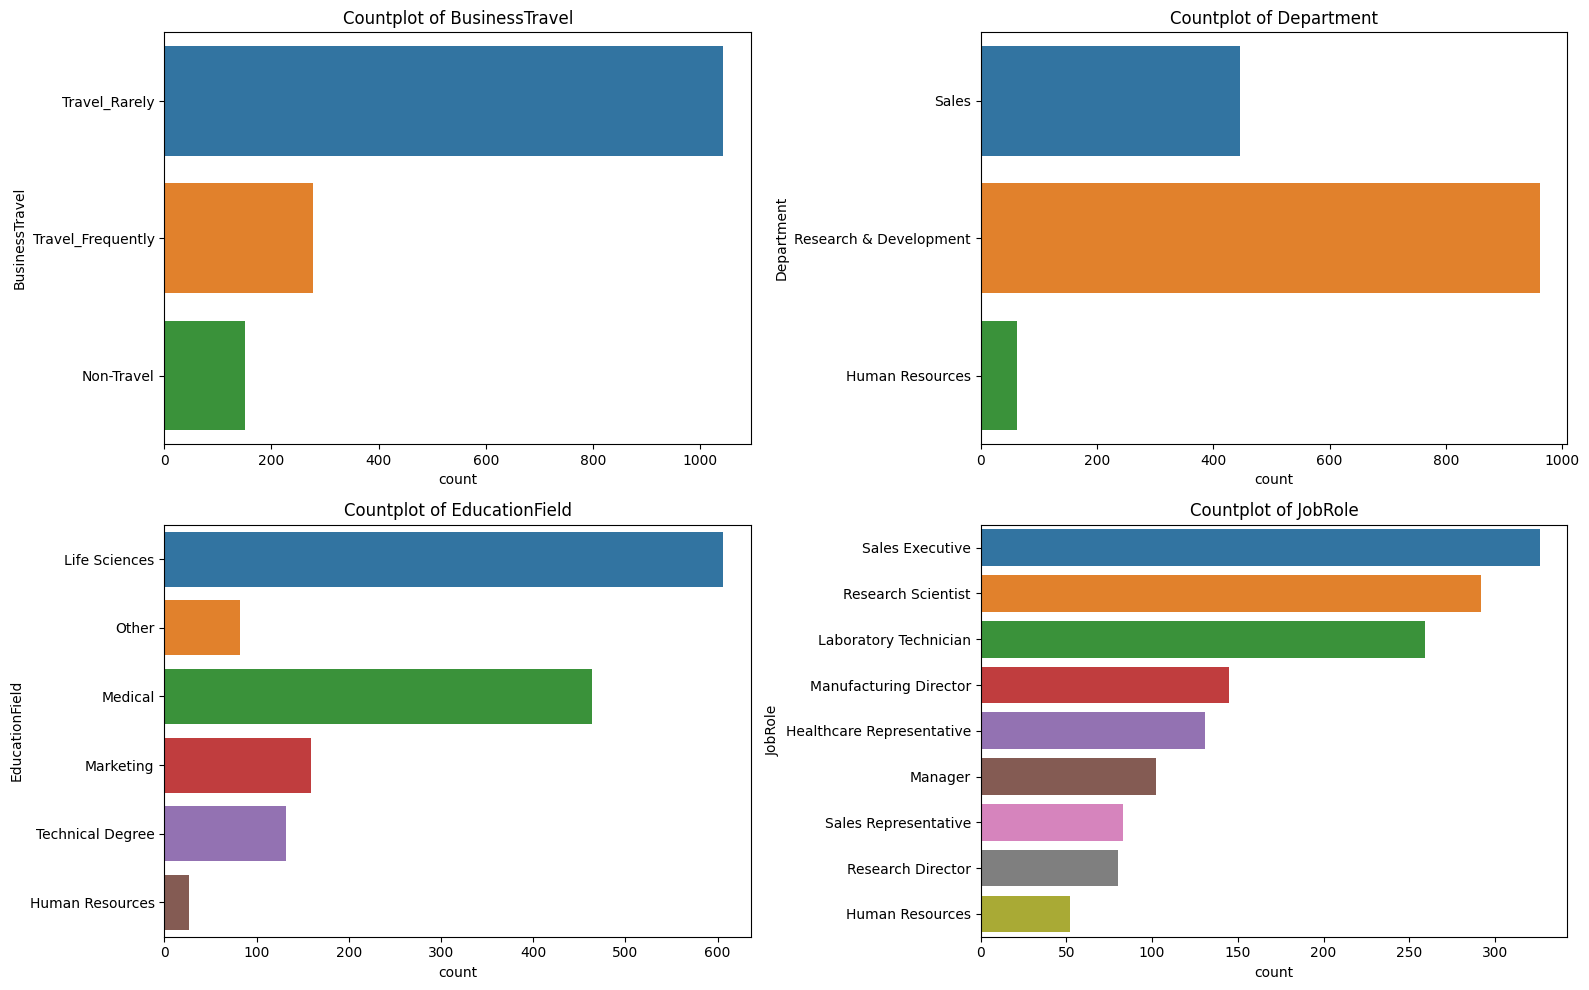

In [333]:
# Categorical Values
list=['BusinessTravel', 'Department', 'EducationField',"JobRole"]

ncols = 2
nrows = math.ceil(len(list) / ncols)

plt.figure(figsize=(16,nrows*5))
for i, obj in enumerate(list):
    ax = plt.subplot(nrows, ncols, i + 1)
    sns.countplot(data=df,y=obj,hue=obj,legend=False)
    ax.set_title(f"Countplot of {obj}")

plt.tight_layout()
plt.show()



## Preprocessing for Training

In [334]:
#Encode Categorical Features obj_list
print(obj_list)
encoder = OneHotEncoder(sparse_output=False)
onehot_encoded = encoder.fit_transform(df[obj_list])
df_encoded=pd.DataFrame(onehot_encoded,columns=encoder.get_feature_names_out(obj_list))
#Check for NaN
print(df_encoded.isnull().sum())
df_encoded.head()

['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']
BusinessTravel_Non-Travel            0
BusinessTravel_Travel_Frequently     0
BusinessTravel_Travel_Rarely         0
Department_Human Resources           0
Department_Research & Development    0
Department_Sales                     0
EducationField_Human Resources       0
EducationField_Life Sciences         0
EducationField_Marketing             0
EducationField_Medical               0
EducationField_Other                 0
EducationField_Technical Degree      0
Gender_Female                        0
Gender_Male                          0
JobRole_Healthcare Representative    0
JobRole_Human Resources              0
JobRole_Laboratory Technician        0
JobRole_Manager                      0
JobRole_Manufacturing Director       0
JobRole_Research Director            0
JobRole_Research Scientist           0
JobRole_Sales Executive              0
JobRole_Sales Representative   

,BusinessTravel_Non-Travel,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Human Resources,Department_Research & Development,Department_Sales,EducationField_Human Resources,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,...,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,Over18_Y,OverTime_No,OverTime_Yes
0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0
1,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
2,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0
3,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
4,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0


In [335]:
# Scale numerical values
sc = StandardScaler()
df[num_list] = sc.fit_transform(df[num_list])
#numerical_scaled = pd.DataFrame(numerical_scaled)
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,0.446350,1,Travel_Rarely,0.742527,Sales,-1.010909,-0.891688,Life Sciences,0.0,-1.701283,...,-1.584178,0.0,-0.932014,-0.421642,-2.171982,-2.493820,-0.164613,-0.063296,-0.679146,0.245834
1,1.322365,0,Travel_Frequently,-1.297775,Research & Development,-0.147150,-1.868426,Life Sciences,0.0,-1.699621,...,1.191438,0.0,0.241988,-0.164511,0.155707,0.338096,0.488508,0.764998,-0.368715,0.806541
2,0.008343,1,Travel_Rarely,1.414363,Research & Development,-0.887515,-0.891688,Other,0.0,-1.696298,...,-0.658973,0.0,-0.932014,-0.550208,0.155707,0.338096,-1.144294,-1.167687,-0.679146,-1.155935
3,-0.429664,0,Travel_Frequently,1.461466,Research & Development,-0.764121,1.061787,Life Sciences,0.0,-1.694636,...,0.266233,0.0,-0.932014,-0.421642,0.155707,0.338096,0.161947,0.764998,0.252146,-1.155935
4,-1.086676,0,Travel_Rarely,-0.524295,Research & Development,-0.887515,-1.868426,Medical,0.0,-1.691313,...,1.191438,0.0,0.241988,-0.678774,0.155707,0.338096,-0.817734,-0.615492,-0.058285,-0.595227


In [336]:
#Combining encoded and numerical values together again

df_to_train = pd.concat([df[num_list],df_encoded],axis=1)
df_to_train.head()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,Over18_Y,OverTime_No,OverTime_Yes
0,0.446350,0.742527,-1.010909,-0.891688,0.0,-1.701283,-0.660531,1.383138,0.379672,-0.057788,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0
1,1.322365,-1.297775,-0.147150,-1.868426,0.0,-1.699621,0.254625,-0.240677,-1.026167,-0.057788,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
2,0.008343,1.414363,-0.887515,-0.891688,0.0,-1.696298,1.169781,1.284725,-1.026167,-0.961486,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0
3,-0.429664,1.461466,-0.764121,1.061787,0.0,-1.694636,1.169781,-0.486709,0.379672,-0.961486,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
4,-1.086676,-0.524295,-0.887515,-1.868426,0.0,-1.691313,-1.575686,-1.274014,0.379672,-0.961486,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0


In [337]:
#Splitting Values into test and train data
y= df["Attrition"]
X = df_to_train

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,stratify=y)

## Logistic Regression Model

In [338]:
#Logisticregression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [339]:
#Calculating Score Metrics
y_pred_lr=lr.predict(X_test)
accuracy_lr=accuracy_score(y_test,y_pred_lr)
conf_matrix= confusion_matrix(y_test,y_pred_lr)
y_proba_lr = lr.predict_proba(X_test)[:,1]
roc_score = roc_auc_score(y_test,y_proba_lr)
print(f'Accuracy Logistic Regression: {accuracy_lr:.2f}')
print(f'ROC AUC Logistic Regression: {roc_score:.2f}')
print(classification_report(y_test,y_pred_lr))

Accuracy Logistic Regression: 0.90
ROC AUC Logistic Regression: 0.87
              precision    recall  f1-score   support

           0       0.91      0.98      0.94       370
           1       0.82      0.51      0.63        71

    accuracy                           0.90       441
   macro avg       0.87      0.74      0.79       441
weighted avg       0.90      0.90      0.89       441



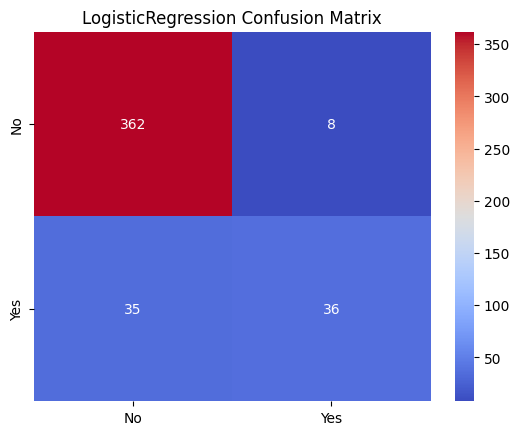

In [340]:
# Now lets visualize the metrics
sns.heatmap(conf_matrix,annot=True,fmt='d',cmap='coolwarm',xticklabels=['No','Yes'],yticklabels=['No','Yes'])
plt.title("LogisticRegression Confusion Matrix")
plt.show()

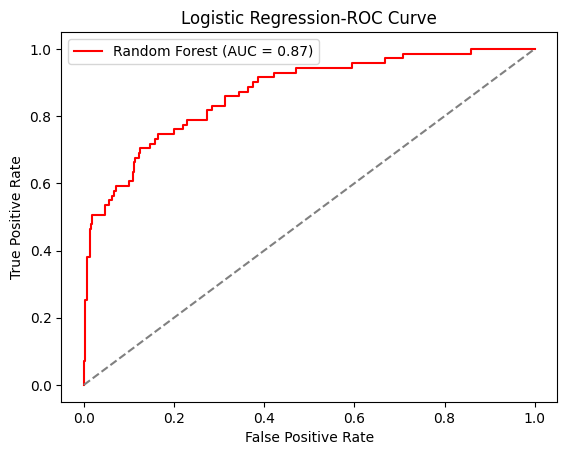

In [341]:
# ROC Curve
fpr_lr ,tpr_lr, _ = roc_curve(y_test,y_proba_lr)
plt.plot(fpr_lr,tpr_lr,label=f"Random Forest (AUC = {roc_score:.2f})",color='Red')
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.title("Logistic Regression-ROC Curve")
plt.show()

In [342]:
pm = permutation_importance(lr, X_test, y_test, n_repeats=10, random_state=42, scoring='accuracy')
sorted_idx=pm.importances_mean.argsort()

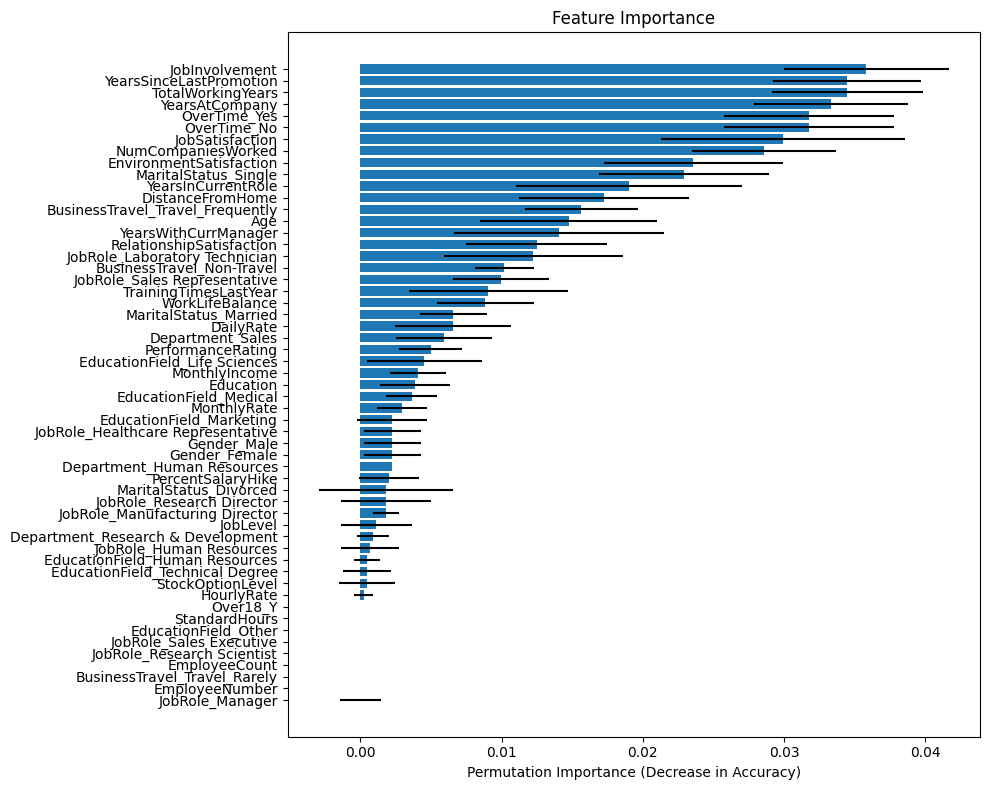

In [343]:
plt.figure(figsize=(10, 8))
plt.barh(range(X_test.shape[1]), pm.importances_mean[sorted_idx], xerr=pm.importances_std[sorted_idx])
plt.yticks(np.arange(X_test.shape[1]), X_test.columns[sorted_idx])
plt.xlabel('Permutation Importance (Decrease in Accuracy)')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

## Random Forest Model

In [344]:
rf = RandomForestClassifier(n_estimators=10)
rf = rf.fit(X_train,y_train)

In [345]:
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:,1]
accuracy_rf=accuracy_score(y_test,y_pred_rf)
conf_matrix= confusion_matrix(y_test,y_pred_rf)
roc_score_rf = roc_auc_score(y_test,y_proba_rf)
print(f'Accuracy Random Forest: {accuracy_rf:.2f}')
print(f'ROC AUC Random Forest: {roc_score_rf:.2f}')
print(classification_report(y_test,y_pred_rf))

Accuracy Random Forest: 0.85
ROC AUC Random Forest: 0.77
              precision    recall  f1-score   support

           0       0.86      0.98      0.92       370
           1       0.68      0.18      0.29        71

    accuracy                           0.85       441
   macro avg       0.77      0.58      0.60       441
weighted avg       0.83      0.85      0.82       441



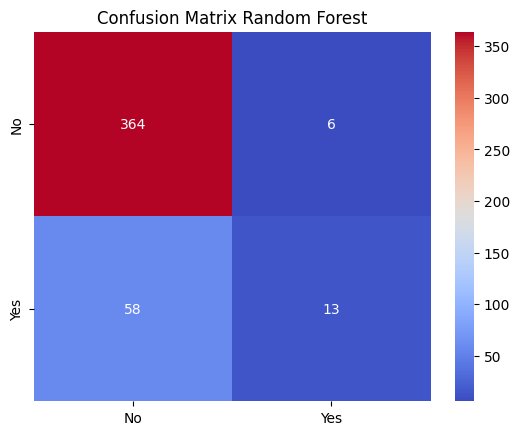

In [346]:
sns.heatmap(conf_matrix,annot=True,fmt='d',cmap='coolwarm',xticklabels=['No','Yes'],yticklabels=['No','Yes'])
plt.title(f"Confusion Matrix Random Forest")
plt.show()

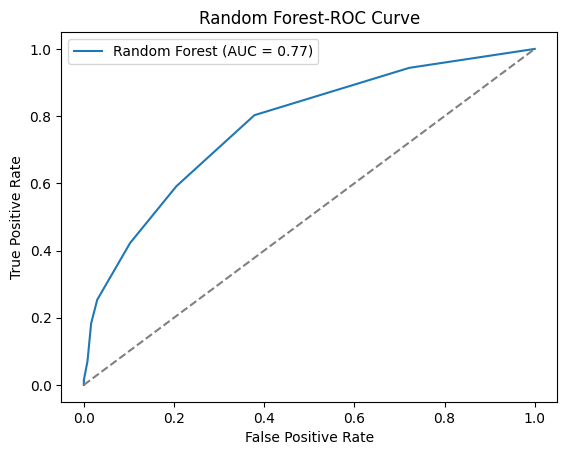

In [347]:
fpr_rf ,tpr_rf, _ = roc_curve(y_test,y_proba_rf)
plt.plot(fpr_rf,tpr_rf,label=f"Random Forest (AUC = {roc_score_rf:.2f})")
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.title("Random Forest-ROC Curve")
plt.show()

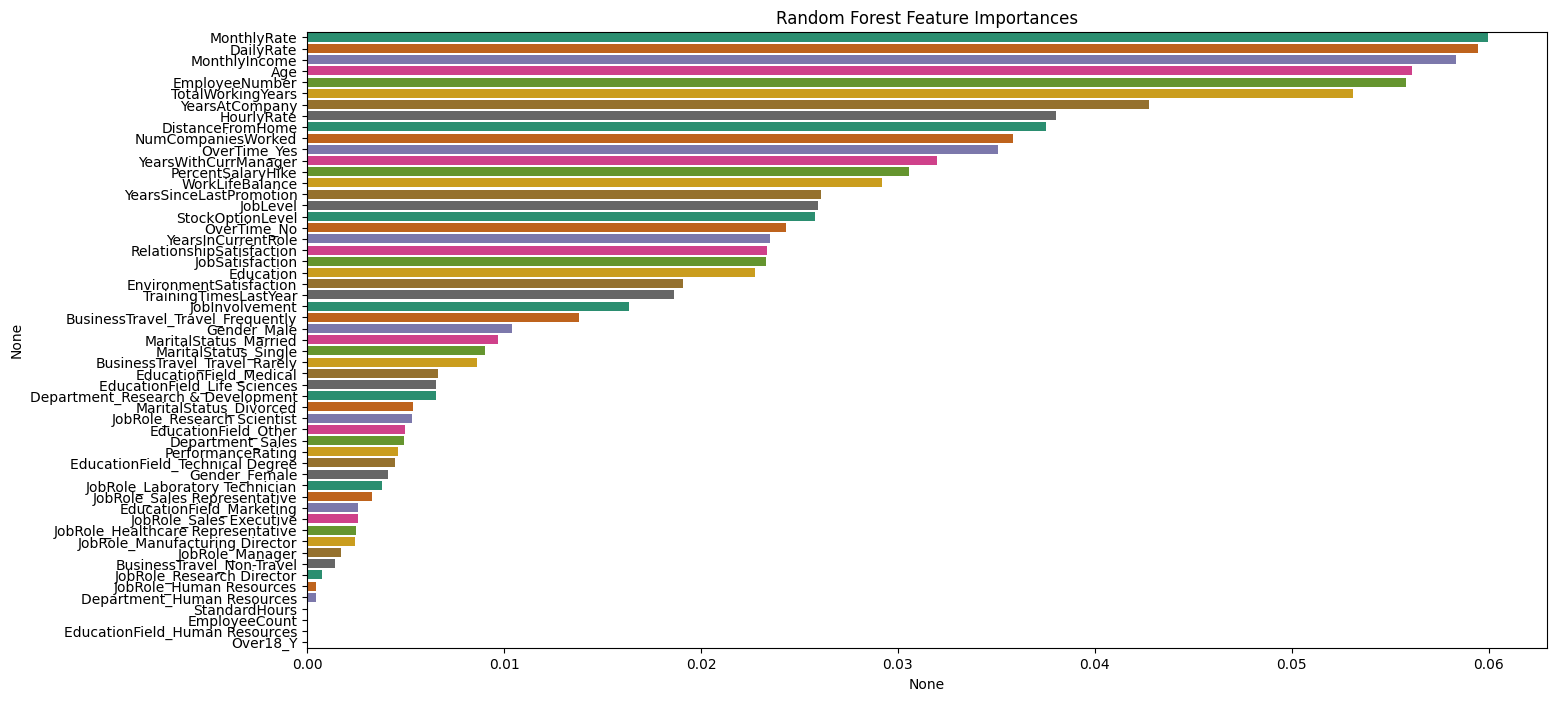

In [348]:
feature_importance=pd.Series(rf.feature_importances_,index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(16,8))
sns.barplot(x=feature_importance,y=feature_importance.index,palette='Dark2',hue=feature_importance.index)
plt.title("Random Forest Feature Importances")
plt.show()

## Compare ROC Curves

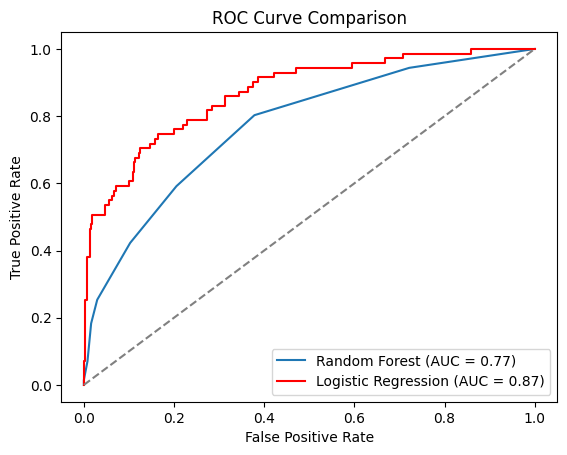

In [350]:
plt.plot(fpr_rf,tpr_rf,label=f"Random Forest (AUC = {roc_score_rf:.2f})")
plt.plot(fpr_lr,tpr_lr,label=f"Logistic Regression (AUC = {roc_score:.2f})",color='Red')
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.title("ROC Curve Comparison")
plt.show()